In [21]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [22]:
#load dataset
df = pd.read_csv("telecom churn.csv")
#Show first 5 rows
print(df.head())

   Account_Length  Vmail_Message  Day_Mins  Eve_Mins  Night_Mins  Intl_Mins  \
0             128             25     265.1     197.4       244.7       10.0   
1             107             26     161.6     195.5       254.4       13.7   
2             137              0     243.4     121.2       162.6       12.2   
3              84              0     299.4      61.9       196.9        6.6   
4              75              0     166.7     148.3       186.9       10.1   

   CustServ_Calls Churn Intl_Plan Vmail_Plan  ...  Day_Charge  Eve_Calls  \
0               1    no        no        yes  ...       45.07         99   
1               1    no        no        yes  ...       27.47        103   
2               0    no        no         no  ...       41.38        110   
3               2    no       yes         no  ...       50.90         88   
4               3    no       yes         no  ...       28.34        122   

   Eve_Charge  Night_Calls  Night_Charge  Intl_Calls  Intl_Charge  S

In [19]:
# Check missing values
print(df.isnull().sum())

Account_Length    0
Vmail_Message     0
Day_Mins          0
Eve_Mins          0
Night_Mins        0
Intl_Mins         0
CustServ_Calls    0
Churn             0
Intl_Plan         0
Vmail_Plan        0
Day_Calls         0
Day_Charge        0
Eve_Calls         0
Eve_Charge        0
Night_Calls       0
Night_Charge      0
Intl_Calls        0
Intl_Charge       0
Area_Code         0
dtype: int64


In [24]:
#Convert text columns to numbers
df['Churn'] = df['Churn'].map({'yes': 1, 'no': 0})
df['Intl_Plan'] = df['Intl_Plan'].map({'yes': 1, 'no': 0})
df['Vmail_Plan'] = df['Vmail_Plan'].map({'yes': 1, 'no': 0})


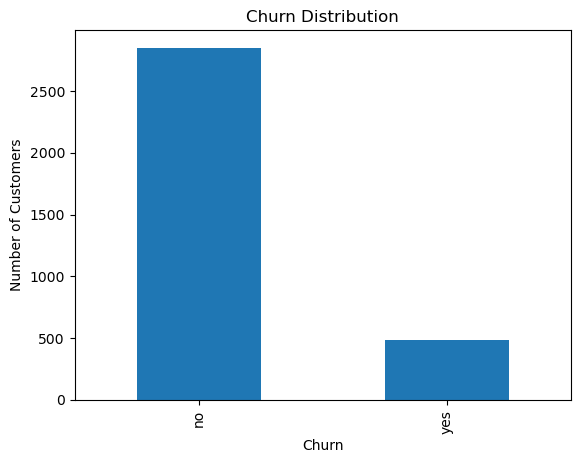

In [23]:
#Graph
df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [25]:
#Remove unnecessary columns
df = df.drop(['Phone', 'State'], axis=1)

In [26]:
#Select input and output
X = df.drop('Churn', axis=1)
y = df['Churn'] 

In [27]:
#Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) 


In [28]:
#Train model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train) 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [29]:
# Predict
y_pred = model.predict(X_test) 

In [30]:
#Check accuracy
print("Accuracy:", accuracy_score(y_test, y_pred)) 

Accuracy: 0.856071964017991


In [31]:
#Check result
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred)) 

Confusion Matrix:
[[553  13]
 [ 83  18]]
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       566
           1       0.58      0.18      0.27       101

    accuracy                           0.86       667
   macro avg       0.73      0.58      0.60       667
weighted avg       0.83      0.86      0.82       667

